# SAXS Analysis Tutorial

The purpose of this notebook is to assist users with classes contained in SAXSAnalysis library. This library contains several Python files, each of them containing dedicated classes.

SAXSAnalysis currently accepts files from 3 different instruments (ESRF, LGC, SWING). Other file formats can be further added by adding the corresponding class in filereaders.py.

Different tasks are separated in dedicated classes, to bring flexibility. Although it may seem more complicated to use, it will allow to modify the code in the future, without having to rewrite everything. These tasks are the following:

### *SAXSProcessor*
 -> class dedicated to data inspection and processing. It allows:

    - Optimized (automatic) reference substraction

    - Automatic caving (image reconstruction based on inversion symmetry)

    - 2D data visualization (q scale)

    - export to sasview

    - extraction of radial profiles in user specified azimuthal directions

    - extraction of azimuthal profiles 

### *CylinderFormFactor*
 -> class dedicated to the calculation of the 2D form factor of a cylinder. It allows:

    - Computation of 2D form factor in q space

    - extraction of azimuthal profile at a given q value

### *NematicOrderCalculator*
 -> class dedicated to the calculation of nematic order parameter. It allows:

    - refinement of experimental azimuthal profiles by th convolution of form factor and Maier-Saupe distribution

### *CorrelationDistanceCalculator (shoud be improved)*
 -> class dedicated to the computation of correlation distances. It allows:

    - determination of peak positions in q space (based on 2nd derivative)

    - calculation of correlation distances

### Test case

The test proposed here is performed on ESRF Data, recorded on ID02. The experiment consists in the alignment of Co12 NRs in toluene, un der a magnetic field. 


The program should work without any problems for LGC data.
For SWING data, results should be double checked, as 2x2 pixels binning is applied.


In [1]:
%matplotlib widget
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

## Define sample files 

As a start, test is performed on a single file. On this file, we will:
- substract reference with optimized code (same procedure as ReduSAXS)
- perform a nice 2D plot $(Q_x,Q_z)$ scale
- extract radial and azimuthal profiles
- compute nematic order parameter

No motor positions provided. Update filereaders.py if required
Optimized k factor for reference subtraction: 0.08581974
Export to SASView 2D format in : ./test_output//Co12_tol1_533.dat


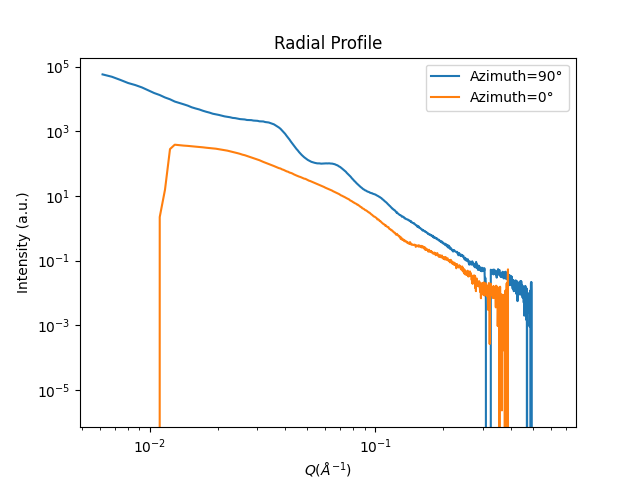

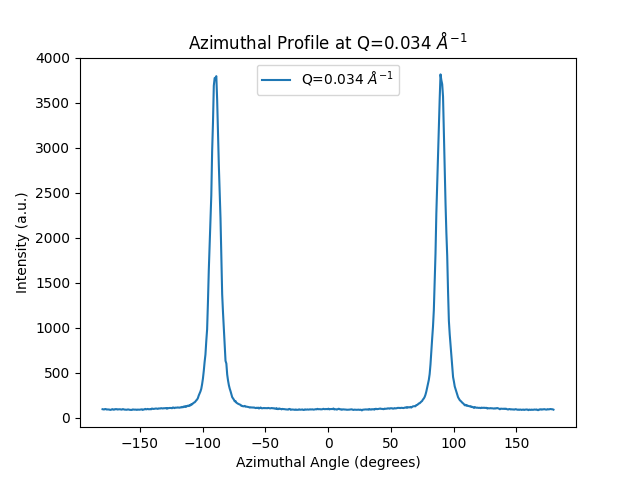

In [2]:
# Define instrument, sample files and paths

instrument='ID02'
mask = './test_data/ref_mask/mask_saxs.edf'
file = './test_data/LPCNOsaxs_eiger2_00533_raw.h5'
reference = './test_data/ref_mask/LPCNOsaxs_eiger2_00467_raw.h5'
output_dir='./test_output/'
os.makedirs(output_dir,exist_ok=True)

# create instance of SAXSDataProcessor
processor = SAXSProcessor(instrument=instrument, file=file, reference_file=reference,autosubstract=True, mask=mask)


# call plot2d_vsq method
#processor.plot2d_vsq(q_range = [0, 0.2],cmap='jet',normalize = True, vmin=-4, output_dir = output_dir)

# extract radial profile
q_radial, intensity_radial_90 = processor.extract_radial_profile(azimuth=90, width=20, save = True,output_dir=output_dir)
q_radial, intensity_radial_0 = processor.extract_radial_profile(azimuth=0, width=20, save = True, output_dir=output_dir)
plt.figure()
plt.loglog(q_radial, intensity_radial_90, label='Azimuth=90°')
plt.loglog(q_radial, intensity_radial_0, label='Azimuth=0°')
plt.xlabel('$Q (\AA^{-1})$')
plt.ylabel('Intensity (a.u.)')
plt.title('Radial Profile')
plt.legend()

# extract azimuthal profile at specific Q
q_value = 0.034
threshold=0.01
chi_exp , I_az_exp = processor.extract_azimuthal_profile(qvalue=q_value, threshold=threshold, output_dir=output_dir)
plt.figure()
plt.plot(chi_exp, I_az_exp, label=f'Q={q_value} $\AA^{{-1}}$')
plt.xlabel('Azimuthal Angle (degrees)')
plt.ylabel('Intensity (a.u.)')
plt.title(f'Azimuthal Profile at Q={q_value} $\AA^{{-1}}$')
plt.legend()


# export data for further use in sasview
processor.export_sasview(output_dir=output_dir)

## Cylinder form factor calculation

At first, we must compute the cylinder form factor (based on sasview). Default parameters correspond to those of Co12 particles, but they may be changed as desired.

The azimuthal profile of form factor will be further convoluted with a Maier Saupe distribution in order to compute the nematic order parameter. 
The CylinderFormFactor class computes the 2D form factor of polydisperse cylinders, WITHOUT any orientation distribution. The orientation distribution is further accounted for by the Maier Saupe distribution, from which is computed the nematic order parameter S.

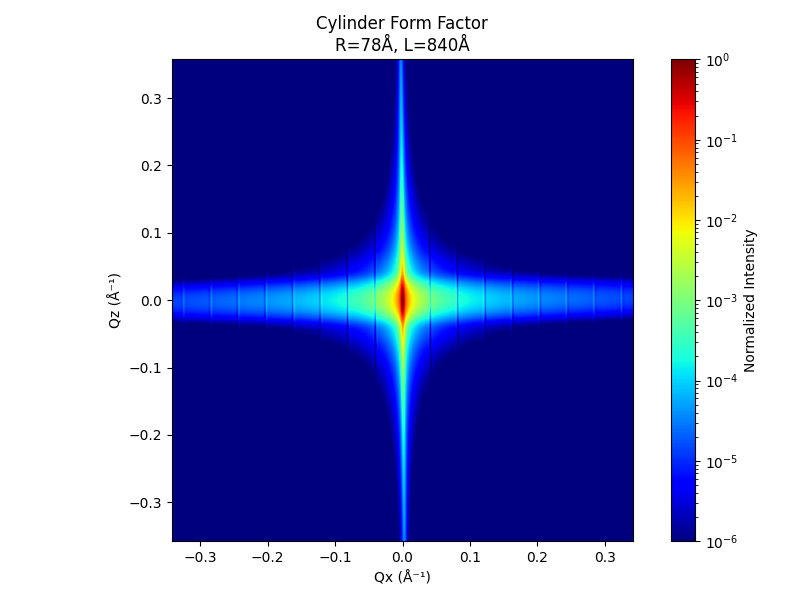

In [3]:
from nematicordercalculator import CylinderFormFactor,NematicOrderCalculator

form_factor = CylinderFormFactor(
    processor=processor, 
    radius=78,
    L=840,
    theta=90,
    phi=0.4,
    radius_pd=0.3,
    L_pd=0.75,
    phi_pd=0,
    theta_pd=0,
    background=0.00001,
    scale=1,
    plot = True
    )

### Azimuthal profile extraction at given q (may be useful)
For good practice, it is shown here how to extract azimuthal profiles at a given q value, without having to recompute the 2D form factor

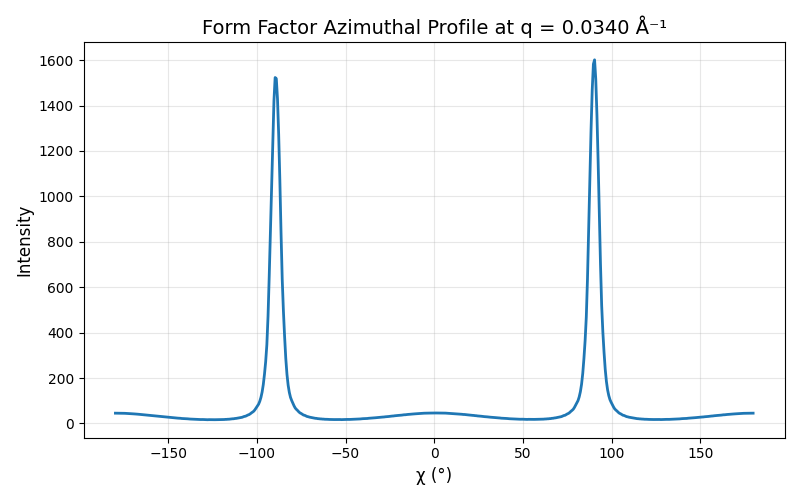

In [4]:
I2D = form_factor.I_ff2D
chi2,I2 = form_factor.extract_azim_profile_formfactor(I2D, q0=0.034, threshold=threshold, plot=True)

### Computation of nematic order parameter @ q = 0.034

Refinement of the experimental aimuthal profile $(\chi_{exp}, I_{az,exp})$ with the convolution of the azimuthal profile of the form factor with Maier Saupe distribution

 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in ./test_data/azimuthal_profiles/Co12_tol1_B=400_Img533_nematic_determination.png

Fitting results:
x0: 90.2678769124741
S: 0.99741092946248
R2: 0.9957239310658679
Nematic order parameter S2 = 0.997 


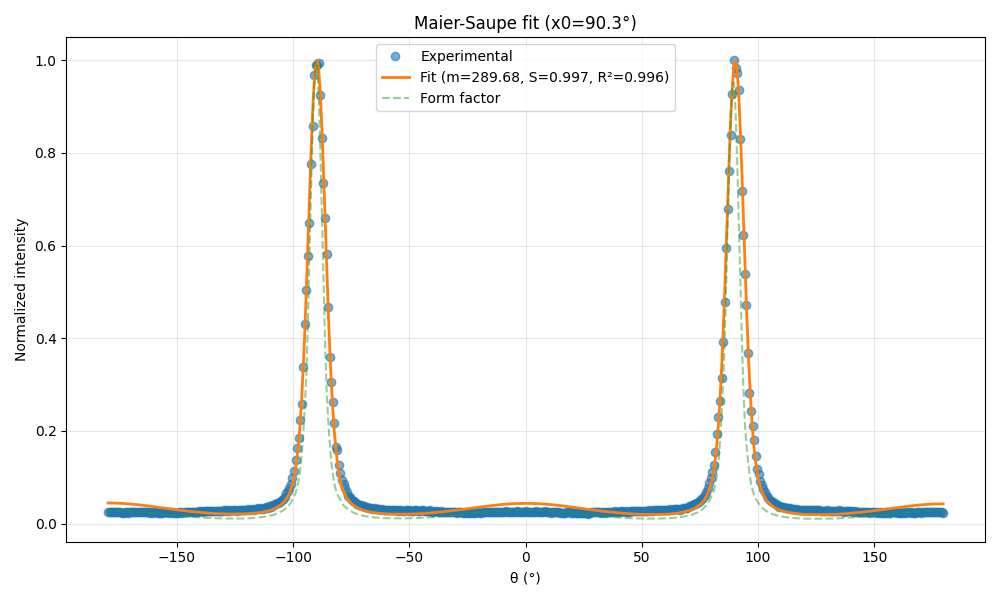

In [5]:
nematic_calc = NematicOrderCalculator(form_factor=form_factor)

results = nematic_calc.fit_azimuthal_profile(chi_exp, I_az_exp, qvalue_ff=0.034, threshold_ff=threshold, plot=True, target=90, apply_mirror=False,processor=processor)
print(f'Nematic order parameter S2 = {results["S"]:.3f} ')

## Test BatchNematic class (automatic batch)

performs the calculation of nematic order parameter on a serie of data files contained in a directory supplied by the user.

### 1. Calculation of Cylinder Formfactor

No motor positions provided. Update filereaders.py if required


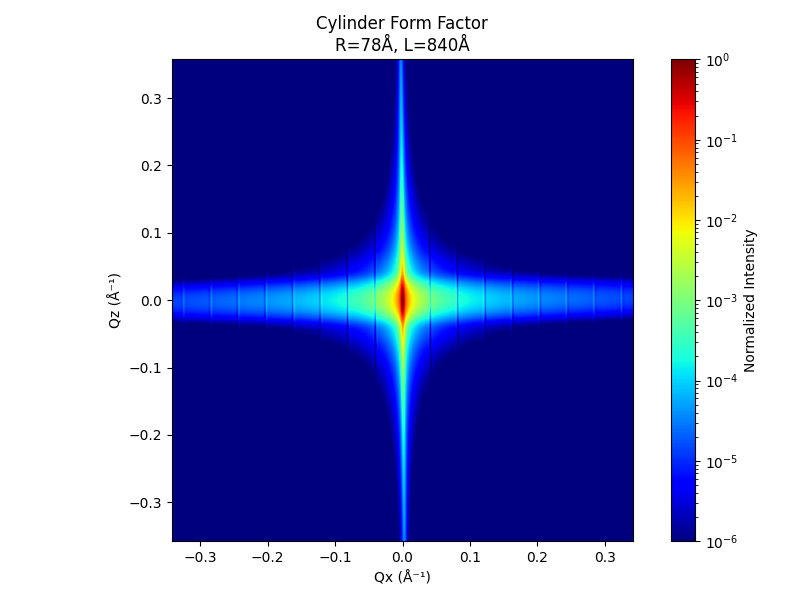

In [6]:
from saxsprocessor import SAXSProcessor
from nematicordercalculator import BatchNematic, CylinderFormFactor,NematicOrderCalculator
# sect q values and threshold at which to extract azimuthal profiles
q_value = 0.034
threshold=0.01


# ----- 1) compute cylinder form factor

# CylinderFormFactor needs a SAXSProcessor instance to get q-mesh and other instrument parameters
file = './test_data/LPCNOsaxs_eiger2_00533_raw.h5' # select a random file for initialization
instrument='ID02'

processor = SAXSProcessor(instrument=instrument, file=file)

form_factor = CylinderFormFactor(
    processor=processor, 
    radius=78,
    L=840,
    theta=90,
    phi=0.4,
    radius_pd=0.3,
    L_pd=0.75,
    phi_pd=0,
    theta_pd=0,
    background=0.00001,
    scale=1,
    plot = True)

### 2. Run Batch

 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q

BatchNematic initialized
Path: ./test_data
Q values: [0.034, 0.068]
Found 7 files to process
Output directory: ./test_output/batch_nematic/


Processing: LPCNOsaxs_eiger2_00528_raw.h5
No motor positions provided. Update filereaders.py if required
Optimized k factor for reference subtraction: 0.09661731

Processing q = 0.0340 Å⁻¹...

ERROR processing LPCNOsaxs_eiger2_00528_raw.h5: cannot access local variable 'figname' where it is not associated with a value

Processing: LPCNOsaxs_eiger2_00529_raw.h5


Traceback (most recent call last):
  File "/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py", line 699, in process_all
    fit_results = self.nematic_calc.fit_azimuthal_profile(
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py", line 242, in fit_azimuthal_profile
    print(f'Fit image saved in {figname}')
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'figname' where it is not associated with a value


No motor positions provided. Update filereaders.py if required
Optimized k factor for reference subtraction: 0.0903595

Processing q = 0.0340 Å⁻¹...

ERROR processing LPCNOsaxs_eiger2_00529_raw.h5: cannot access local variable 'figname' where it is not associated with a value

Processing: LPCNOsaxs_eiger2_00530_raw.h5


Traceback (most recent call last):
  File "/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py", line 699, in process_all
    fit_results = self.nematic_calc.fit_azimuthal_profile(
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py", line 242, in fit_azimuthal_profile
    print(f'Fit image saved in {figname}')
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'figname' where it is not associated with a value


No motor positions provided. Update filereaders.py if required
Optimized k factor for reference subtraction: 0.08857801

Processing q = 0.0340 Å⁻¹...

ERROR processing LPCNOsaxs_eiger2_00530_raw.h5: cannot access local variable 'figname' where it is not associated with a value

Processing: LPCNOsaxs_eiger2_00531_raw.h5


...

No motor positions provided. Update filereaders.py if required
Optimized k factor for reference subtraction: 0.08581974

Processing q = 0.0340 Å⁻¹...

ERROR processing LPCNOsaxs_eiger2_00533_raw.h5: cannot access local variable 'figname' where it is not associated with a value

Processing: LPCNOsaxs_eiger2_00534_raw.h5


Traceback (most recent call last):
  File "/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py", line 699, in process_all
    fit_results = self.nematic_calc.fit_azimuthal_profile(
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py", line 242, in fit_azimuthal_profile
    print(f'Fit image saved in {figname}')
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'figname' where it is not associated with a value


No motor positions provided. Update filereaders.py if required
Optimized k factor for reference subtraction: 0.08372588

Processing q = 0.0340 Å⁻¹...

ERROR processing LPCNOsaxs_eiger2_00534_raw.h5: cannot access local variable 'figname' where it is not associated with a value

Saving results...
✓ Log file saved: ./test_output/batch_nematic/batch_processing.log
⚠ No successful fits to save


Traceback (most recent call last):
  File "/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py", line 699, in process_all
    fit_results = self.nematic_calc.fit_azimuthal_profile(
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py", line 242, in fit_azimuthal_profile
    print(f'Fit image saved in {figname}')
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'figname' where it is not associated with a value


""


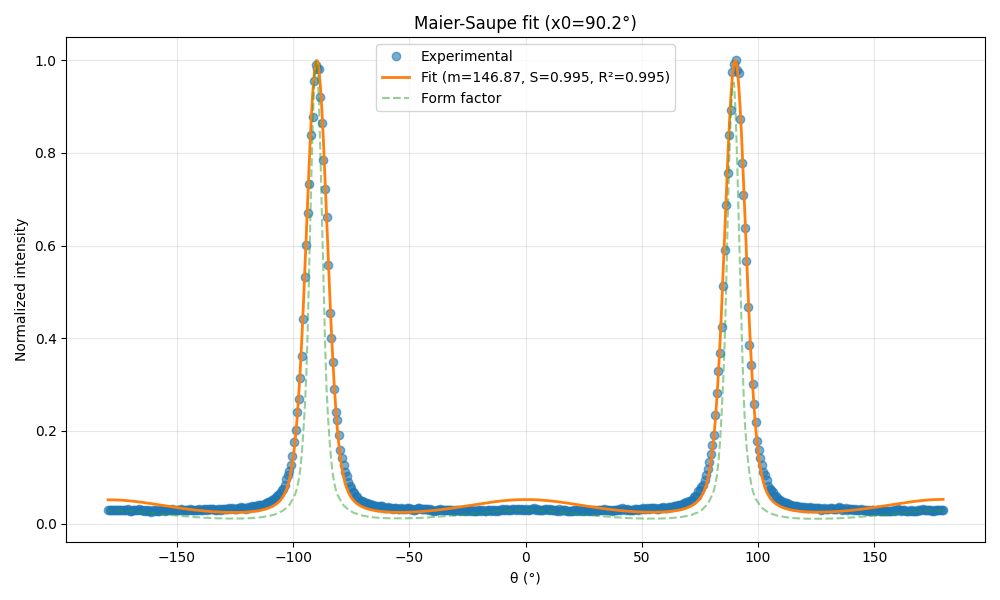

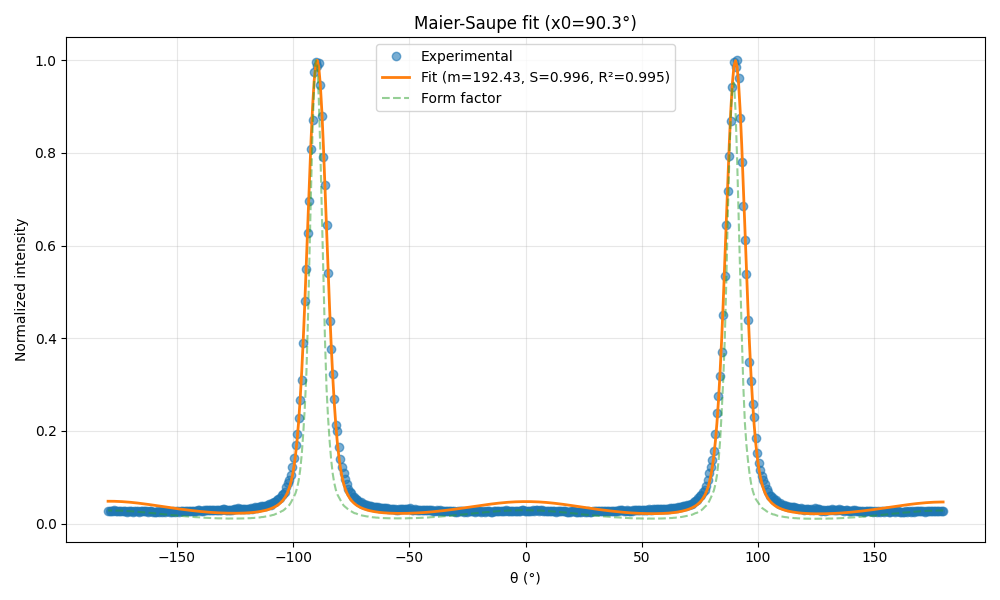

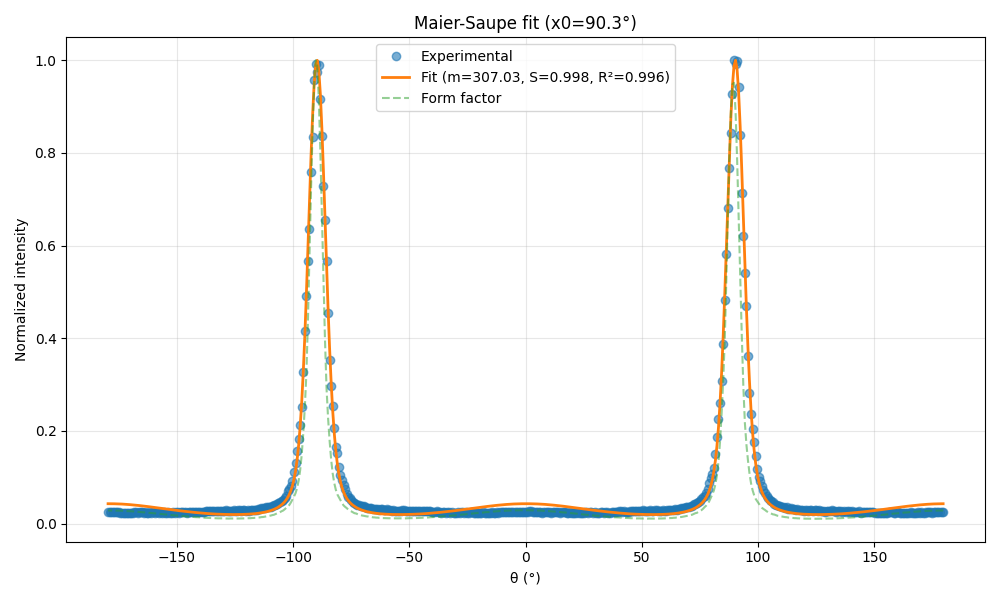

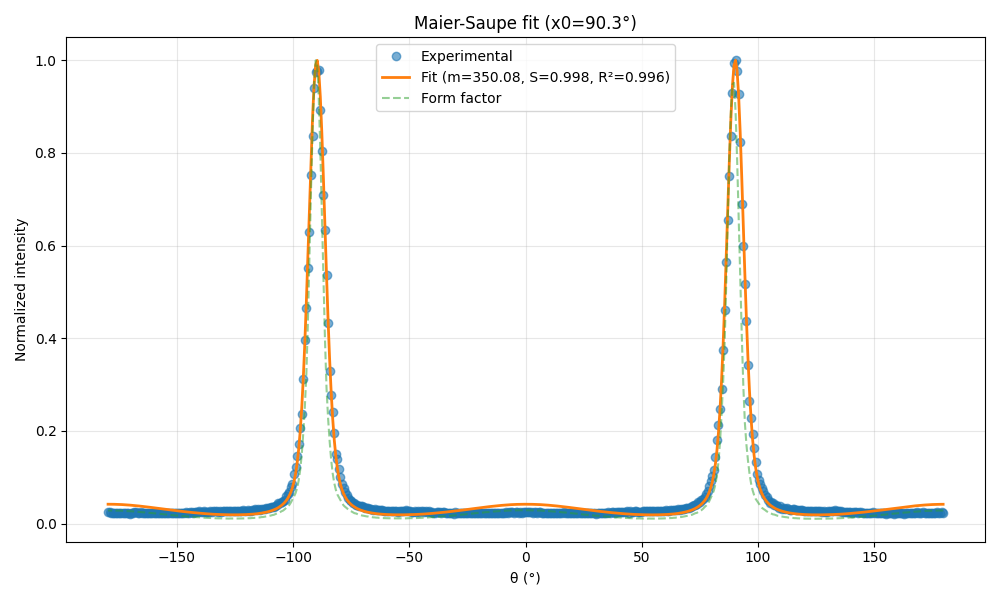

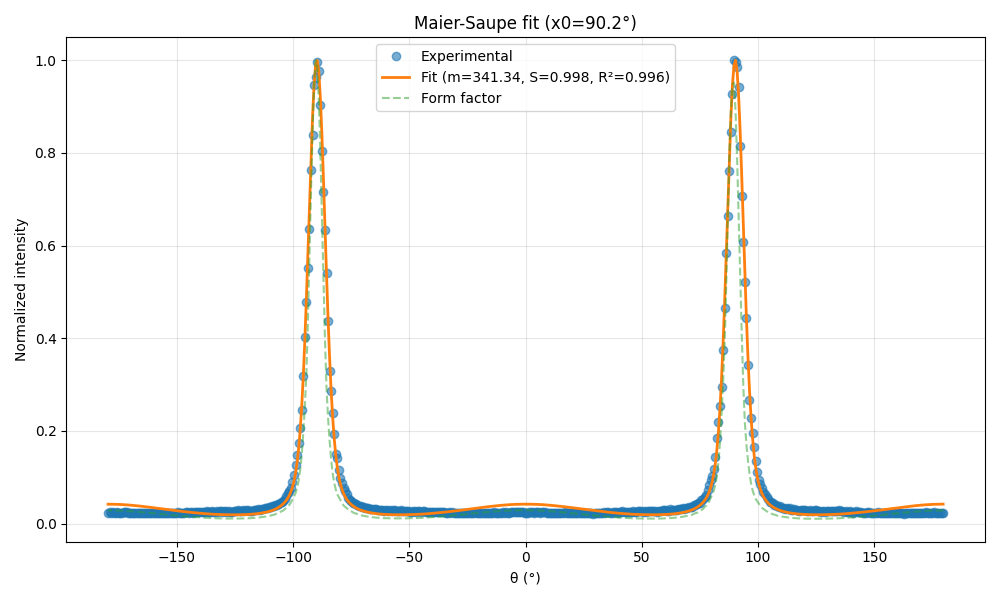

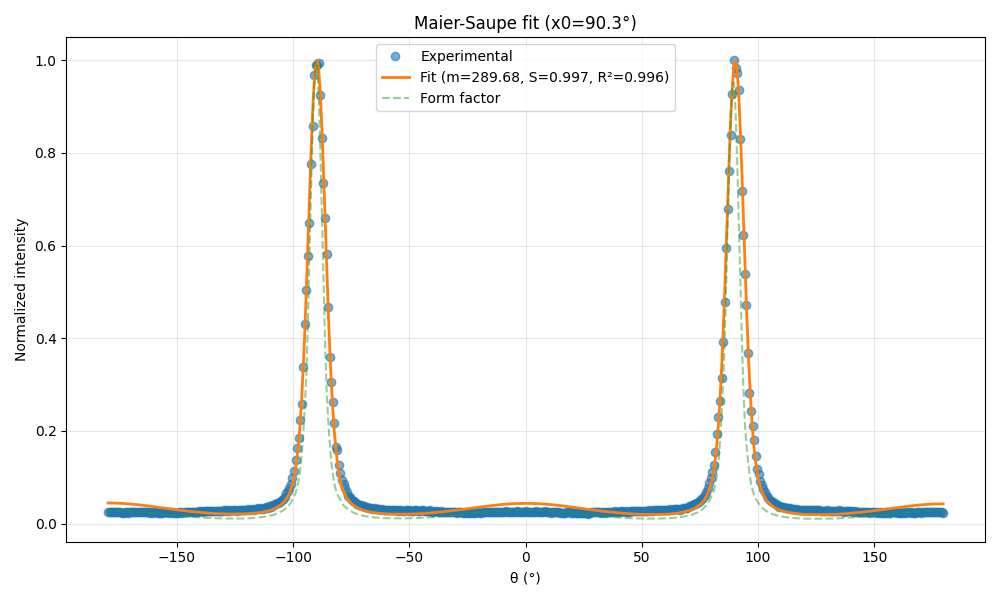

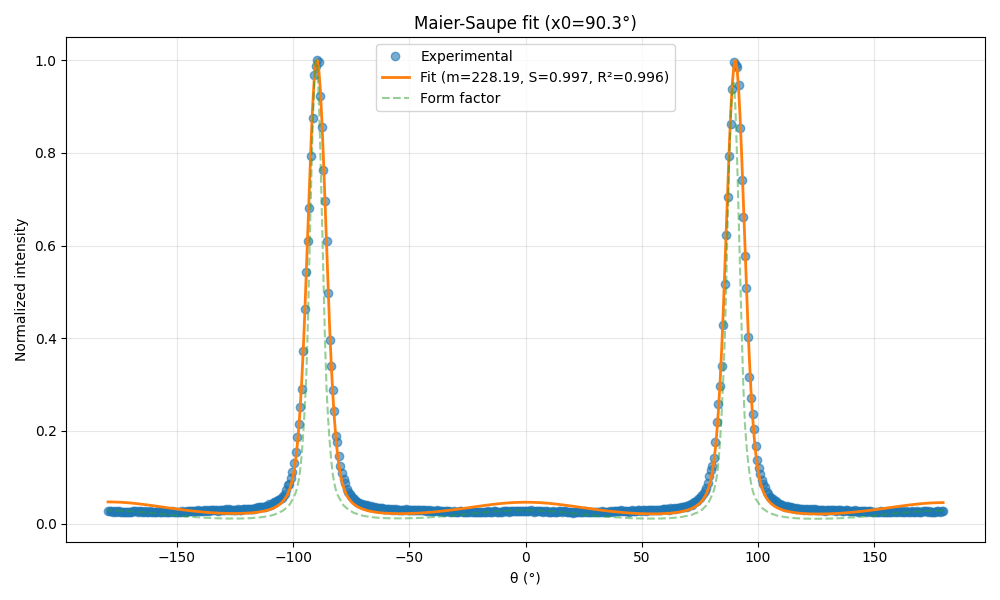

In [7]:
# select data path, reference file, mask, qvalues, threshold
path = './test_data'
reference = './test_data/ref_mask/LPCNOsaxs_eiger2_00467_raw.h5'
mask = './test_data/ref_mask/mask_saxs.edf'
qvalues = [0.034, 0.068]
threshold=0.01
output_dir='./test_output/batch_nematic/'

batch= BatchNematic(
    instrument=instrument,
    path=path,
    qvalues=qvalues,
    threshold=threshold,
    reference_file=reference,
    autosubstract=True,
    mask=mask,
    file_filter = '*eiger2_005*.h5', #ensures we select only sample files
    form_factor=form_factor,    
    output_dir=output_dir
)
batch.process_all(save_profiles=True,plot =True)